# Tomato Leaf Disease Classification - Model Evaluation
This notebook loads the trained models from the training phase and performs final evaluation and comparison.

- Load saved trained models
- Recreate test generators
- Compute confusion matrices
- Generate classification reports
- Compare final model performance
- Visualize sample predictions

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

## Paths and Configuration
Define dataset paths, model paths, and image settings used in evaluation.

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "split_dataset/train"
val_dir = "split_dataset/val"
test_dir = "split_dataset/test"

model_dir = "final_model"

custom_cnn_model_path = os.path.join(model_dir, "best_custom_cnn_model.keras")
efficientnet_model_path = os.path.join(model_dir, "best_efficientnet_model.keras")
mobilenet_model_path = os.path.join(model_dir, "best_mobilenet_model.keras")

training_summary_path = os.path.join(model_dir, "training_summary.csv")

## Recreate Test Generators
Create separate test generators for:
- Custom CNN
- EfficientNetB0
- MobileNetV2

In [ ]:
# Custom CNN test generator
cnn_test_datagen = ImageDataGenerator(rescale=1./255)

test_generator_cnn = cnn_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# EfficientNet test generator
efficientnet_test_datagen = ImageDataGenerator()

test_generator_efficientnet = efficientnet_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# MobileNetV2 test generator
mobilenet_test_datagen = ImageDataGenerator()

test_generator_mobilenet = mobilenet_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 676 images belonging to 3 classes.
Found 676 images belonging to 3 classes.
Found 676 images belonging to 3 classes.


## Load Saved Models
Load all trained models from the training notebook.

In [ ]:
# Load Custom CNN
best_custom_cnn_model = load_model(custom_cnn_model_path)

# Load EfficientNetB0
best_efficientnet_model = load_model(
    efficientnet_model_path,
    custom_objects={"preprocess_input": efficientnet_preprocess},
    safe_mode=False
)

# Load MobileNetV2
best_mobilenet_model = load_model(
    mobilenet_model_path,
    custom_objects={"preprocess_input": mobilenet_preprocess},
    safe_mode=False
)

print("All models loaded successfully.")


All models loaded successfully.


## Load Training Summary
Load the summary generated in the training notebook for reference.

In [ ]:
training_summary = pd.read_csv(training_summary_path)
training_summary

,Model,Final Train Accuracy,Best Val Accuracy,Test Accuracy,Test Loss
0,Custom CNN,0.884408,0.891852,0.893491,0.247707
1,EfficientNetB0,0.961893,0.970370,0.973373,0.088813
2,MobileNetV2,0.953636,0.945185,0.940828,0.154006


## Reusable Evaluation Function
This function evaluates a model on a given test generator and returns:
- test loss
- test accuracy
- predictions
- true labels
- classification report
- confusion matrix

In [ ]:
def evaluate_model(model, generator, class_labels, model_name="Model"):
    generator.reset()

    y_prob = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = generator.classes

    test_loss, test_acc = model.evaluate(generator, verbose=0)

    print(f"\n{'='*60}")
    print(f"{model_name} Test Loss: {test_loss:.4f}")
    print(f"{model_name} Test Accuracy: {test_acc:.4f}")
    print(f"{'='*60}\n")

    print(f"Classification Report for {model_name}:\n")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    return {
        "test_loss": test_loss,
        "test_acc": test_acc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

## Evaluate Custom CNN
Compute classification report and confusion matrix for the Custom CNN model.

22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step

Custom CNN Test Loss: 0.2477
Custom CNN Test Accuracy: 0.8935

Classification Report for Custom CNN:

                     precision    recall  f1-score   support

Tomato_Early_blight       0.85      0.67      0.75       150
 Tomato_Late_blight       0.84      0.93      0.88       287
     Tomato_healthy       0.99      0.99      0.99       239

           accuracy                           0.89       676
          macro avg       0.89      0.86      0.87       676
       weighted avg       0.89      0.89      0.89       676



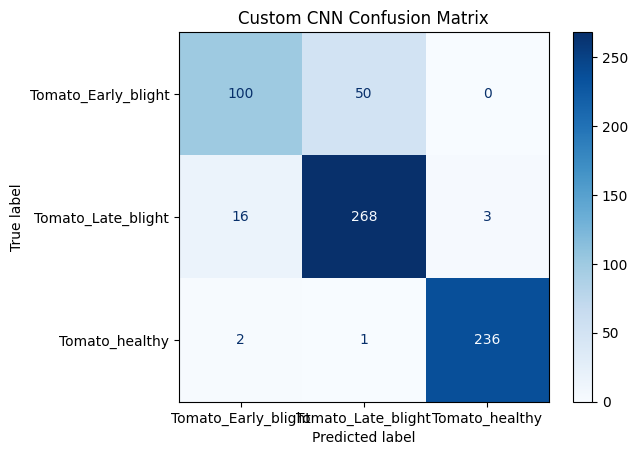

In [ ]:
class_labels_cnn = list(test_generator_cnn.class_indices.keys())

cnn_results = evaluate_model(
    model=best_custom_cnn_model,
    generator=test_generator_cnn,
    class_labels=class_labels_cnn,
    model_name="Custom CNN"
)

## Evaluate EfficientNetB0
Compute classification report and confusion matrix for the EfficientNetB0 model.

22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 868ms/step

EfficientNetB0 Test Loss: 0.0888
EfficientNetB0 Test Accuracy: 0.9734

Classification Report for EfficientNetB0:

                     precision    recall  f1-score   support

Tomato_Early_blight       0.93      0.97      0.95       150
 Tomato_Late_blight       0.99      0.95      0.97       287
     Tomato_healthy       0.98      1.00      0.99       239

           accuracy                           0.97       676
          macro avg       0.97      0.97      0.97       676
       weighted avg       0.97      0.97      0.97       676



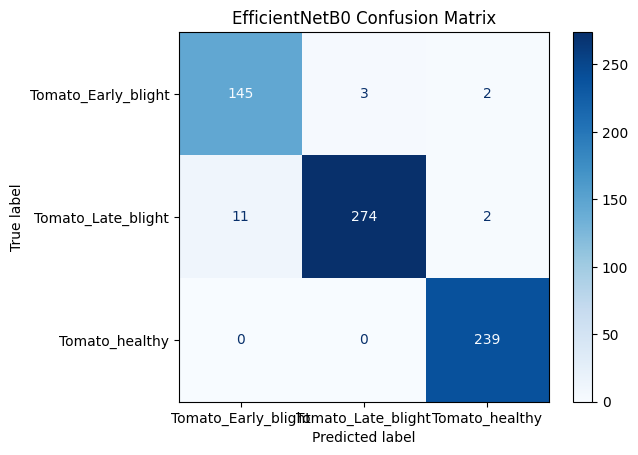

In [ ]:
class_labels_efficientnet = list(test_generator_efficientnet.class_indices.keys())

efficientnet_results = evaluate_model(
    model=best_efficientnet_model,
    generator=test_generator_efficientnet,
    class_labels=class_labels_efficientnet,
    model_name="EfficientNetB0"
)

## Evaluate MobileNetV2
Compute classification report and confusion matrix for the MobileNetV2 model.

22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 686ms/step

MobileNetV2 Test Loss: 0.1540
MobileNetV2 Test Accuracy: 0.9408

Classification Report for MobileNetV2:

                     precision    recall  f1-score   support

Tomato_Early_blight       0.88      0.89      0.88       150
 Tomato_Late_blight       0.95      0.92      0.93       287
     Tomato_healthy       0.97      1.00      0.99       239

           accuracy                           0.94       676
          macro avg       0.93      0.94      0.93       676
       weighted avg       0.94      0.94      0.94       676



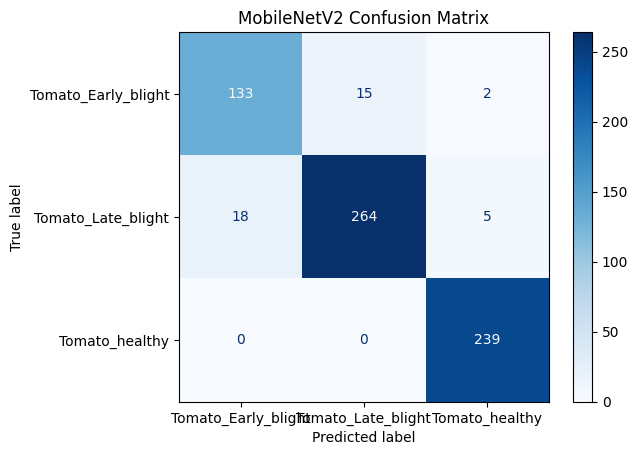

In [ ]:
class_labels_mobilenet = list(test_generator_mobilenet.class_indices.keys())

mobilenet_results = evaluate_model(
    model=best_mobilenet_model,
    generator=test_generator_mobilenet,
    class_labels=class_labels_mobilenet,
    model_name="MobileNetV2"
)

## Final Evaluation Comparison Table
Create a final comparison table using the evaluation results from all three models.

In [ ]:
evaluation_summary = pd.DataFrame({
    "Model": ["Custom CNN", "EfficientNetB0", "MobileNetV2"],
    "Test Accuracy": [
        cnn_results["test_acc"],
        efficientnet_results["test_acc"],
        mobilenet_results["test_acc"]
    ],
    "Test Loss": [
        cnn_results["test_loss"],
        efficientnet_results["test_loss"],
        mobilenet_results["test_loss"]
    ]
})

evaluation_summary

,Model,Test Accuracy,Test Loss
0,Custom CNN,0.893491,0.247707
1,EfficientNetB0,0.973373,0.088813
2,MobileNetV2,0.940828,0.154006


## Plot Final Model Comparison
Visualize the final comparison across all three models.

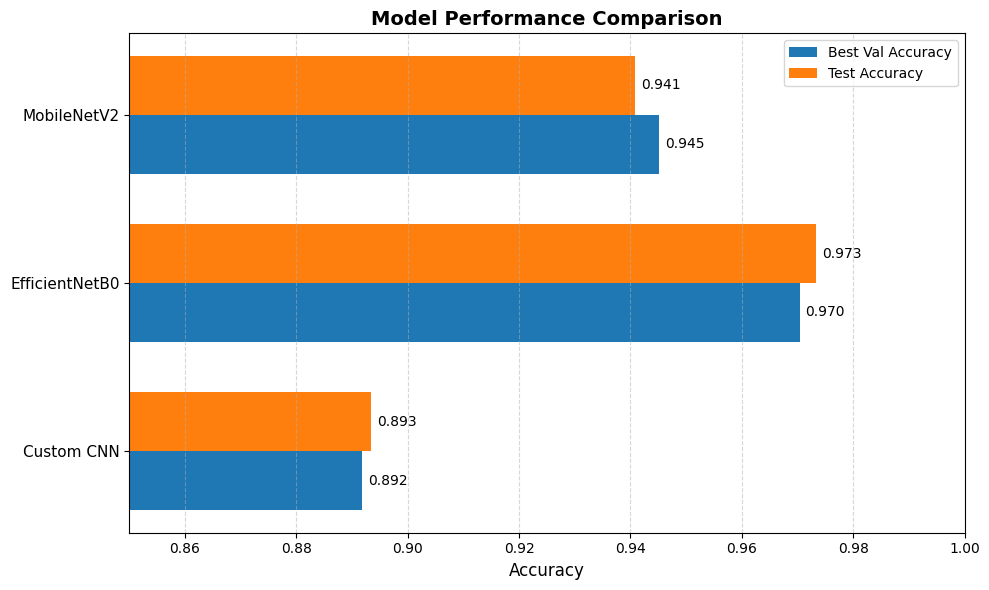

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models = training_summary["Model"]
best_val_acc = training_summary["Best Val Accuracy"]
test_acc = training_summary["Test Accuracy"]

y = np.arange(len(models))
height = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.barh(y - height/2, best_val_acc, height, label="Best Val Accuracy")
bars2 = plt.barh(y + height/2, test_acc, height, label="Test Accuracy")

plt.yticks(y, models, fontsize=11)
plt.xlim(0.85, 1.00)
plt.xlabel("Accuracy", fontsize=12)
plt.title("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        width_val = bar.get_width()
        plt.text(
            width_val + 0.001,
            bar.get_y() + bar.get_height()/2,
            f"{width_val:.3f}",
            va='center',
            fontsize=10
        )

plt.tight_layout()
plt.show()

## Sample Predictions from the Best Model
Display sample test images with:
- true class
- predicted class
- confidence score

The best model in this project is EfficientNetB0.

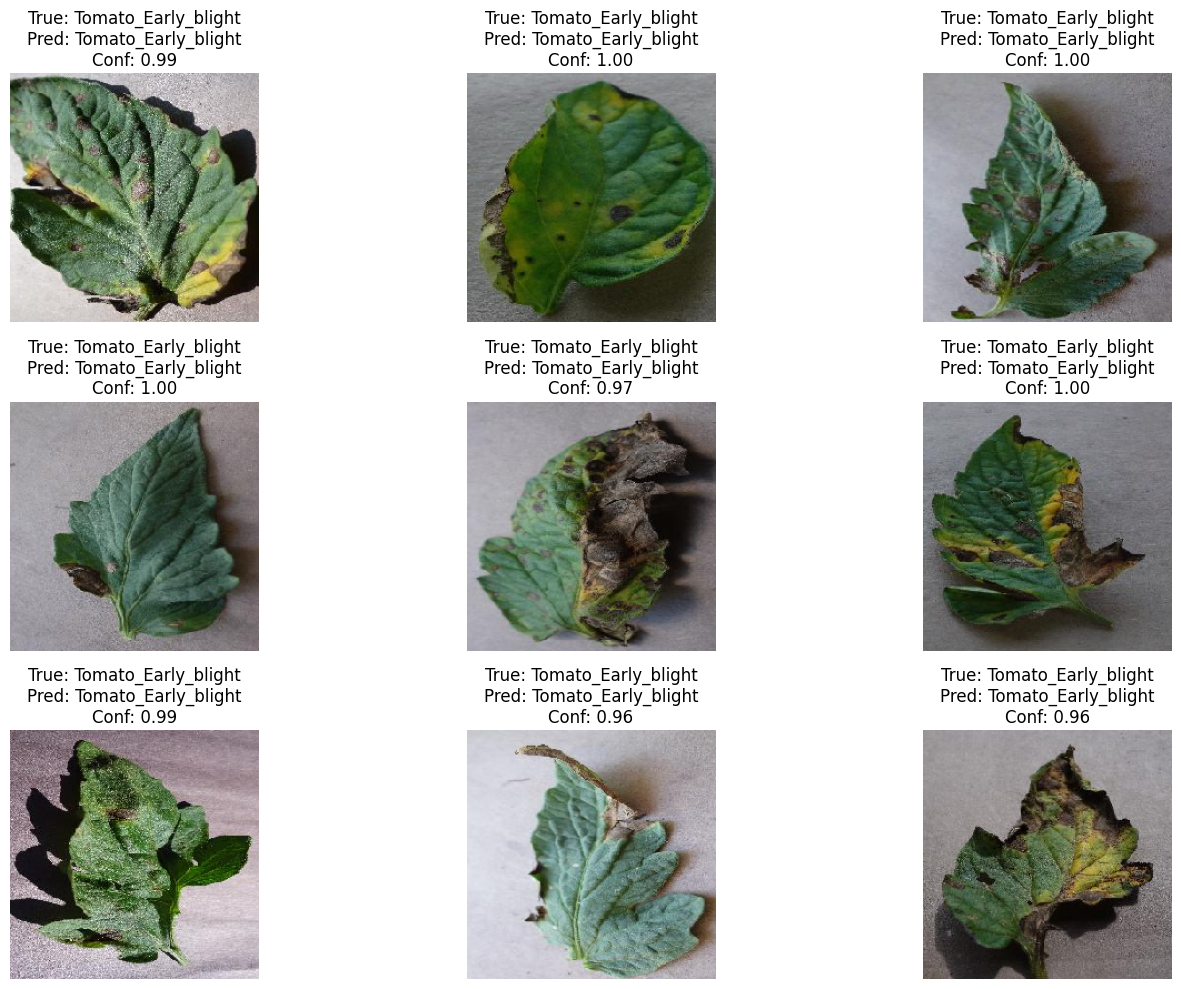

In [ ]:
filepaths = test_generator_efficientnet.filepaths
index_to_class = {v: k for k, v in test_generator_efficientnet.class_indices.items()}

plt.figure(figsize=(15, 10))

for i in range(9):
    img_path = filepaths[i]
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)

    input_arr = np.expand_dims(img_array, axis=0)
    pred_prob = best_efficientnet_model.predict(input_arr, verbose=0)
    pred_class_idx = np.argmax(pred_prob, axis=1)[0]
    pred_class_name = index_to_class[pred_class_idx]
    confidence = np.max(pred_prob)

    true_class_name = os.path.basename(os.path.dirname(img_path))

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_class_name}\nPred: {pred_class_name}\nConf: {confidence:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Misclassified Samples from the Best Model
Display test images where the final selected model made incorrect predictions.

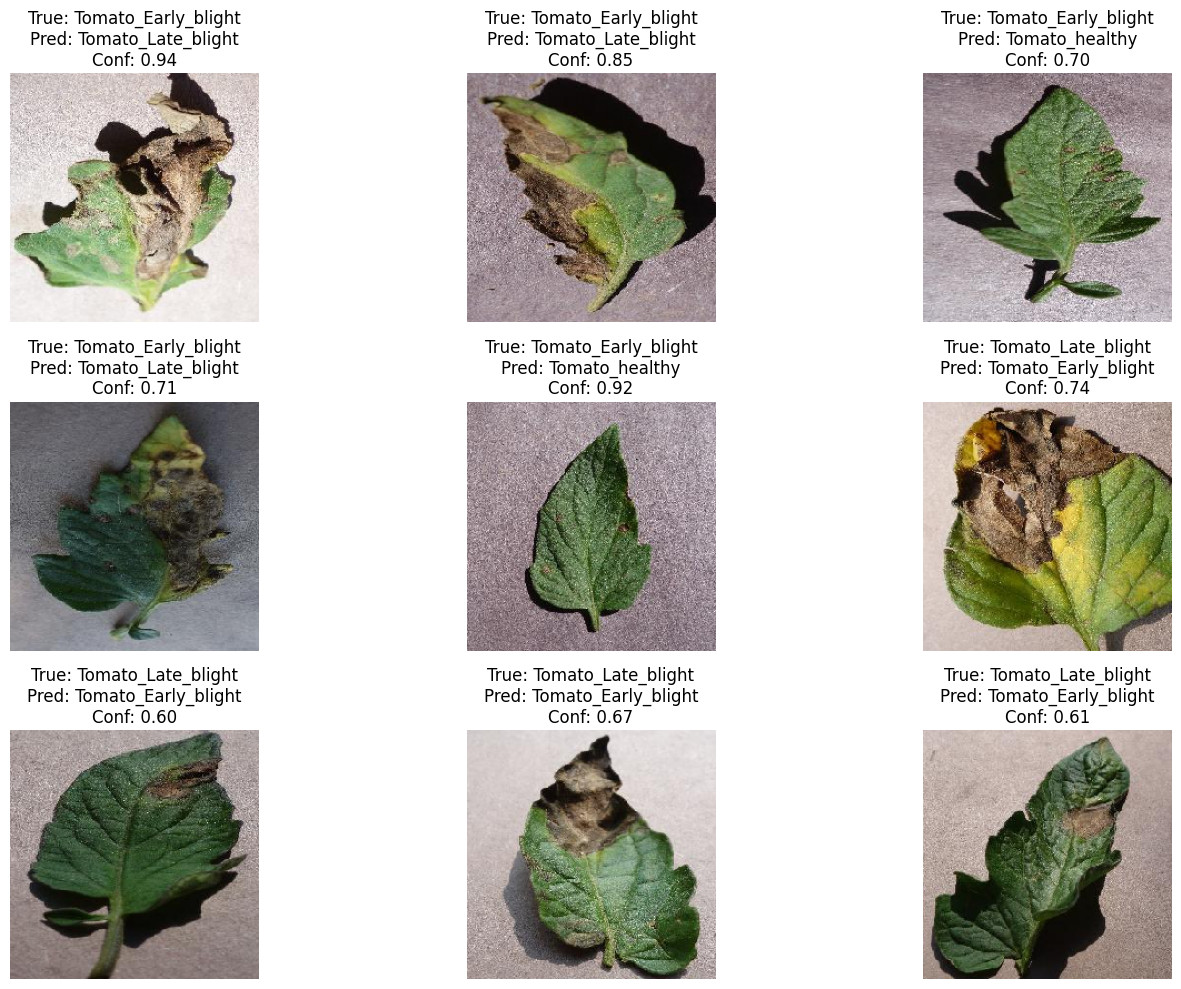

In [ ]:
misclassified_indices = np.where(efficientnet_results["y_true"] != efficientnet_results["y_pred"])[0]

plt.figure(figsize=(15, 10))

for i, idx in enumerate(misclassified_indices[:9]):
    img_path = filepaths[idx]
    img = load_img(img_path, target_size=IMG_SIZE)

    true_class_name = index_to_class[efficientnet_results["y_true"][idx]]
    pred_class_name = index_to_class[efficientnet_results["y_pred"][idx]]
    confidence = np.max(efficientnet_results["y_prob"][idx])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_class_name}\nPred: {pred_class_name}\nConf: {confidence:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()